<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents

- [Imports](#imports)
- [Part 1](#part-1)
- [Part 2](#part-2)
- [Part 3](#part-3)
- [Part 4](#part-4)
- [Part 5](#part-5)
- [Part 6](#part-6)

</div>

### ORIENTATION:

Just the code and deliverable information pertaining to hw5 instructions for COMP3703

[Kaggle Dataset Used - https://www.kaggle.com/datasets/jancsg/cybersecurity-suspicious-web-threat-interactions](https://www.kaggle.com/datasets/jancsg/cybersecurity-suspicious-web-threat-interactions)

[Upload Work Here](https://classroom.github.com/a/tzCvid0H)

---

### SUMMARY:
- Part 1
    - Generic Q/As
- Part 2
    - Acquire data
    - Clean data
    - Encode/Normalize data
    - Split into train/val/test dataset
- Part 3
    - Define architecture
        - Fully connected feedforward NN
        - <= 3 hidden layers
        - ReLU activations
        - Sigmoid output
    - Train NN
    - Plot train/val loss and accuracy
    - Report final test performance
- Part 4
    - Train Random Forest Classifier
    - Compare accuracy, precision, recall, F1 score, false pos/neg
- Part 5
    - Try to identify at least 5 misclassified examples
    - Categorize failure types (Noise, ambiguous, class overlap, labeling error)
    - Explain potential exploitation by attackers
- Part 6
    - Generic Q/As

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier

2026-02-28 21:46:10.293068: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Part 1

- [Back to Table of Contents](#table-of-contents)

</div>

- What is the attacker behavior we are trying to detect?
    - Classification of a benign vs. Distributed Denial of Service (DDoS) since this will likely be the most obvious thing to distinguish without applying anything complex for this assignment
- What does a false positive cost?
    - Will flag benign attacks as DDoS causing meaningless allocation of time and resources and less trust in the model's predictions
- What does a false negative cost?
    - Will flag DDoS attacks as benign allowing for exploits in the system to remain indefinitely until caught by the model or an individual furthering mistrust and waste of resources due to the model
- Why a neural network might help (or not help)?
    - Helpful largely because it can ingest large data and apply math/statistics to derive underlying patterns and better guesses sooner than a human could.  However, depending on the data and how the model is coded to operate can corrupt, invalidate, and/or limit what the model is capable of.  Basically the same concept of a calculator, if typed correctly, computes most algebra significantly faster than a human could, but more complex equations like integrals and multi-variable calculus is generally outside the scope of what a calculator can feasably achieve.  Though a NN is more capable than a calculator, the NN is not at the level to understand concepts that fall outside just rote application of statistics and core equations derived from mathematicians, thus anything (like complex network ideology for example) outside this scope, the NN will fail to derive and since it does not reason the fundamental 'why' in underlying computations, it will only reason with numbers and not understand why things like a datapoint that fall outside a particular range in a Tukey method is considered an outlier.  It just understands that a point falls within that outlier range.

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Part 2

- [Back to Table of Contents](#table-of-contents)

</div>

In [2]:
# Use cleaned short version of dataset from final project since it should align with Amazon CloudWatch requirements (And cause why re-do work! :D)
df = pd.read_parquet('clean_short.parquet')
df.head(3)

,ipv4_src_addr,l4_src_port,ipv4_dst_addr,l4_dst_port,protocol,l7_proto,in_bytes,in_pkts,out_bytes,out_pkts,...,tcp_win_max_out,icmp_type,icmp_ipv4_type,dns_query_id,dns_query_type,dns_ttl_answer,ftp_command_ret_code,label,attack,dataset
53864551,192.168.1.31,38428,192.168.35.45,443,6,91.0,44,1,0,0,...,0,0,0,0,0,0,0.0,1,scanning,nf-ton-iot-v2
1117388,192.168.1.34,37921,192.168.1.49,83,6,0.0,44,1,0,0,...,0,0,0,0,0,0,0.0,0,benign,nf-ton-iot-v2
24149364,192.168.100.150,39164,192.168.100.3,80,17,188.0,56,2,0,0,...,0,0,0,0,0,0,0.0,1,ddos,nf-bot-iot-v2


In [3]:
# Reduce the dataframe for simplicity and time's sake
# Remove every entry that is not 'benign' or 'ddos' type attack
df = df[df['attack'].isin(['benign', 'ddos'])]

# Remove all unnecessary features for simplicity and time's sake
features_to_keep = ['l4_src_port',
                    'l4_dst_port',
                    'protocol',
                    'in_bytes',
                    'in_pkts',
                    'out_bytes',
                    'out_pkts',
                    'flow_duration_milliseconds',
                    'attack']
df = df[features_to_keep]

In [4]:
# Apply encoding and normalization where necessary
# Encode attack types
df['attack'] = df['attack'].map({'benign': 0, 'ddos': 1})

# Encode protocol
df = pd.get_dummies(df, columns=['protocol'], prefix='protocol')

# Normalize numeric features
features_to_scale = ['in_bytes',
                     'in_pkts',
                     'out_bytes',
                     'out_pkts',
                    'flow_duration_milliseconds']
scaler = RobustScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df.head(3)

,l4_src_port,l4_dst_port,in_bytes,in_pkts,out_bytes,out_pkts,flow_duration_milliseconds,attack,protocol_1,protocol_2,protocol_6,protocol_17,protocol_47,protocol_58,protocol_89,protocol_132
1117388,37921,83,-0.113208,-0.25,-0.140845,-0.333333,0.000000,0,False,False,True,False,False,False,False,False
24149364,39164,80,-0.056604,0.00,-0.140845,-0.333333,0.999978,1,False,False,False,True,False,False,False,False
17494595,30256,3389,8.929245,3.00,2.549296,2.666667,0.000000,0,False,False,True,False,False,False,False,False


In [5]:
# Split into train, val, test datasets
seed = 3703

X = df.drop(columns=['attack'])
y = df['attack']

# Do a 70-20-10 split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.30, random_state=seed, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.33, random_state=seed, stratify=y_val)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Part 3

- [Back to Table of Contents](#table-of-contents)

</div>

In [17]:
# Determine input shape dynamically based on your X_train columns
input_dim = X_train.shape[1]

model = models.Sequential([
    # Hidden Layer 1: 16 neurons
    layers.Dense(16, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.1), # Small dropout to prevent memorizing specific IP patterns
    
    # Hidden Layer 2: 8 neurons
    layers.Dense(8, activation='relu'),
    
    # Output Layer: 1 neuron (Sigmoid for 0-1 probability)
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/COMP3703/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Stop if validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=1024,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6038 - loss: 82.7233 - val_accuracy: 0.7114 - val_loss: 1.8873
Epoch 2/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6862 - loss: 5.9881 - val_accuracy: 0.8258 - val_loss: 0.9057
Epoch 3/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7130 - loss: 2.0444 - val_accuracy: 0.6774 - val_loss: 0.8944
Epoch 4/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7247 - loss: 0.9181 - val_accuracy: 0.7304 - val_loss: 0.5282
Epoch 5/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7307 - loss: 0.7696 - val_accuracy: 0.7216 - val_loss: 0.6086
Epoch 6/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7491 - loss: 0.5984 - val_accuracy: 0.7515 - val_loss: 0.5075
Epoch 7/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7953 - loss: 0.4356 - val_accuracy: 0.7541 - val_loss: 0.4287
Epoch 8/50
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8323 - loss: 0.3938 -

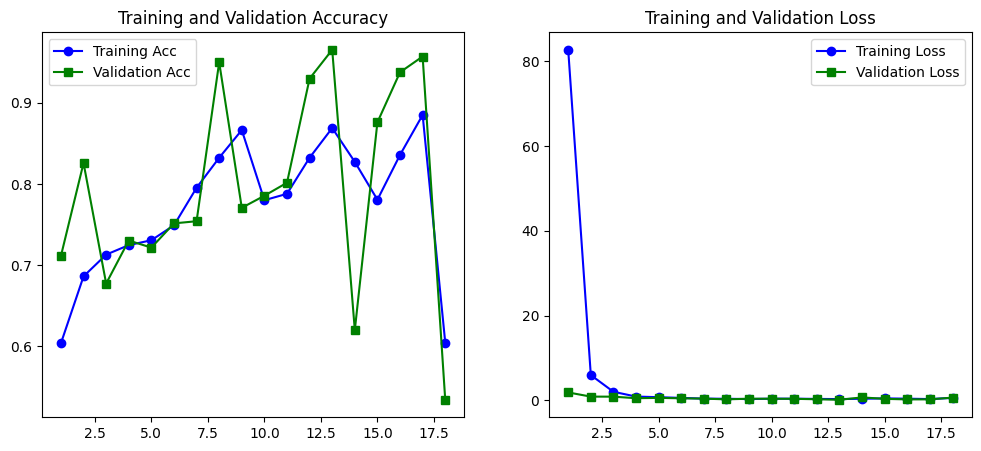

In [21]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'gs-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss') 
    plt.plot(epochs, val_loss, 'gs-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [22]:
# Get predictions (0.0 to 1.0)
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)

# Report performance
print("--- Final Test Performance ---")
print(classification_report(y_test, y_pred, target_names=['Benign', 'DDoS']))

# Confusion Matrix
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

7257/7257 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
--- Final Test Performance ---
              precision    recall  f1-score   support

      Benign       0.96      0.98      0.97    124569
        DDoS       0.97      0.95      0.96    107624

    accuracy                           0.97    232193
   macro avg       0.97      0.96      0.96    232193
weighted avg       0.97      0.97      0.97    232193

--- Confusion Matrix ---
[[121611   2958]
 [  5156 102468]]


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Part 4

- [Back to Table of Contents](#table-of-contents)

</div>

In [ ]:
# Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [11]:
# Calculate Confusion Matrices
cm_nn = confusion_matrix(y_test, y_pred) # From your NN code
cm_rf = confusion_matrix(y_test, y_pred_rf)

def print_errors(cm, name):
    tn, fp, fn, tp = cm.ravel()
    print(f"--- {name} ---")
    print(f"False Positives (Benign marked as Attack): {fp}")
    print(f"False Negatives (Attack marked as Benign): {fn}")

print_errors(cm_nn, "Neural Network")
print_errors(cm_rf, "Random Forest")

--- Neural Network ---
False Positives (Benign marked as Attack): 4745
False Negatives (Attack marked as Benign): 4341
--- Random Forest ---
False Positives (Benign marked as Attack): 74
False Negatives (Attack marked as Benign): 100


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Part 5

- [Back to Table of Contents](#table-of-contents)

</div>

In [14]:
def get_misclassified(X_test, y_test, y_pred, model_name="Model"):
    # Create a temporary DataFrame to align everything
    results = X_test.copy()
    results['true_label'] = y_test.values
    results['pred_label'] = y_pred.flatten()
    
    # Filter for rows where true != pred
    misclassified = results[results['true_label'] != results['pred_label']]
    
    print(f"\n--- {model_name}: Found {len(misclassified)} misclassified examples ---")
    # Return the first 5 examples
    return misclassified.head(5)

# For the Neural Network
nn_errors = get_misclassified(X_test, y_test, y_pred, "Neural Network")

# Display the errors
print(nn_errors)


--- Neural Network: Found 9086 misclassified examples ---
          l4_src_port  l4_dst_port  in_bytes  in_pkts  out_bytes  out_pkts  \
625460           3304            1 -0.132075    -0.25   0.000000  0.000000   
68668173        11545          445  0.301887     0.25   0.323944  0.666667   
45324778        14433           81 -0.132075    -0.25  -0.140845 -0.333333   
71146962         1043           53  0.301887    -0.25  -0.140845 -0.333333   
27631397        33138           80  1.933962     1.00   1.221831  1.000000   

          flow_duration_milliseconds  protocol_1  protocol_2  protocol_6  \
625460                           0.0       False       False        True   
68668173                         0.0       False       False        True   
45324778                         0.0       False       False        True   
71146962                         0.0       False       False       False   
27631397                         0.0       False       False        True   

          proto

I've never done cybersecurity so I don't know what exactly is pertinent off of first glance

- 625460
    - Type: Logic Error (Negative value weighting?)
    - Exploit: To avoid being flagged, ensure you receive/send a positive normalized value.  Or overload the system with negatives to destroy confidence/trust in the model
- 68668173
    - Type: Logic Error (Difference of in/out too similar?)
    - Exploit: To avoid being flagged, ensure you receive/send a positive normalized value where the difference between in/out is at least 0.3.  Or overload the system with the opposite to destroy confidence/trust in the model
- 45324778
    - Type: Logic Error (Negative value weighting?)
    - Exploit: To avoid being flagged, ensure you receive/send a positive normalized value.  Or overload the system with negatives to destroy confidence/trust in the model
- 71146962
    - Type: Logic Error (Negative value weighting?)
    - Exploit: To avoid being flagged, ensure you receive/send a positive normalized value.  Or overload the system with negatives to destroy confidence/trust in the model
- 27631397
    - Type: Logic Error (Negative value weighting?)
    - Exploit: To avoid being flagged, ensure you receive/send a positive normalized value.  Or overload the system with negatives to destroy confidence/trust in the model

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Part 6

- [Back to Table of Contents](#table-of-contents)

</div>

- Should this model operate fully autonomously?
    - No, and generally any model should never be fully autonomous for the reason stated in part 1.4.  Models do not understand 'why' and only reason via provided statistics and mathematical equations meaning they are extremely susceptible to data poisoning, algorithm corruption, and miscoded steps
- How should analysts interact with the system?
    - Assuming the analyst is just a subject matter expert (SME) in their respective field that is not CS and AI, they should work with the CS/AI worker to determine what needs to be done for the SME to understandd what is being outputted, how the output should be formatted to streamline understanding, and most importantly, what the CS/AI worker needs to implement to ensure the system is being utilized optimally
- What are the ethical risks of false accusations?
    - Besides the obvious notion of false imprisonment in a legal sense, it destroys the underlying trust in AI and it is always harder to earn trust than it is to build trust
- How could model bias manifest in cybersecurity?
    - Mathematically speaking, extremely large and small values that are not normalized.  Categorically speaking, strings that mean the same thing, but are typed differently (DDoS, ddos, DdoS, etc.).  Database-wise, duplicate entries and duplicate features.  Model training-wise, the concepts of underfitting and overfitting data.  Methodology-wise, target variable leakage into training data (Like if the target is type of animal such as mammal and a feature with entries like the scientific equivalent mammalia is used for training).  When feature engineering, if one engineers multiple features that are all derived from the same feature (The model may establish a pattern due to over-abundance of occurance for a single value).  If the data itself is extremely biased to begin with or the target variable exhibits a biased distribution (i.e. 99% to 1%)